<a href="https://colab.research.google.com/github/caioadlc/NN_and_DL/blob/main/CNN_mnist_cifar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Context
Esse notebook tem como objetivo comparar o desempenho dos algoritmos *Multi Layer Perceptron* (*MLP*) e Convolutional *Neural Network* (*CNN*), na classificação de imagens utilizando datasets de diferentes níveis de complexidade.

O *MLP* é uma técnica que utiliza redes neurais completamente conectadas, cada neurônio de uma camada $i$ se conecta a todos os neurônios da camada $i+1$. Nessa estrutura, cada neurônio recebe uma combinação linear da saída das ativações anteriores (mais um bias), seguida de uma funçao de ativação não linear. Isso permite que a rede aprenda as características globais dos dados de entrada.
![MLP Architecture](https://stanford.edu/~shervine/teaching/cs-229/illustrations/neural-network-en.png)
*Source: Stanford University - CS 229 - Deep Learning

Por outro lado, o *CNN* utiliza filtros convolucionais (`kernels`) para identificar uma determinada característica dos dados de entrada, como bordas, texturas, formas, etc.

![CNN Architecture](https://stanford.edu/~shervine/teaching/cs-230/illustrations/architecture-cnn-en.jpeg)
*Source: Stanford University - CS 230 - Deep Learning

Espera-se que, o *MLP* tenha um bom desempenho na tarefa de classificar imagens simples, e a medida que aumentamos a complexidade das imagens ele perca desempenho. Com isso, o *CNN* se mostrará um algoritmo com maior poder de classificação, devido sua natureza de explorar estruturas espaciais das imagens.


DataSets:
 - **MNIST**: Base composta por imagens em escala cinza de dimensão 28x28, que representam digitos manuscritos de 0 a 9.
 - **CIFAR100**: Base composta por imagens coloridas de dimensão 32x32, distribuídas em 100 classes distintas.

# 0. Imports

In [2]:
!pip install umap-learn shap catboost imgaug

In [3]:
# Sistema
import os
import zipfile

# Principais imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl
import datetime
# from google.colab import drive
# drive.mount('/content/drive')

# Classificadores
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier # Arvore de Decisao
from sklearn.ensemble import RandomForestClassifier # Floresta de Decisao
from sklearn.svm import SVC # Support Vector Machine
from xgboost import XGBClassifier # XGBoost
from lightgbm import LGBMClassifier # LGBM
from sklearn.svm import LinearSVC # Linear Support Vector Machine
from sklearn.dummy import DummyClassifier # Classificador aleatorio
from catboost import CatBoostClassifier # CatBoost
from sklearn.linear_model import LogisticRegression # Regressao Logistica

# Clustering
from sklearn.cluster import KMeans

# Avaliadores
from sklearn.metrics import classification_report # Acc, Precision, Recall e F1-Score
from sklearn.metrics import ConfusionMatrixDisplay # Matriz de confusao
from sklearn.metrics import roc_auc_score # area sob curva roc
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, accuracy_score # Metricas
from sklearn.model_selection import cross_val_score # CrossValidation com uma metrica
from sklearn.model_selection import cross_validate # CrossValidation com mais de uma metrica

# Pre processamento
from sklearn.preprocessing import StandardScaler # Normaliza feature media = 0 e desvpad = 1
from sklearn.preprocessing import OneHotEncoder # Encoda uma coluna categorica
from sklearn.impute import SimpleImputer # Imputer: Preenche uma determinada feature
from imblearn.over_sampling import SMOTE # SMOTE

# Datasets nativos SKLearn
from sklearn.datasets import load_digits # Digitos Manuscritos

# DeepLearning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

# Utilidades
from sklearn.pipeline import make_pipeline # Cria pipeline
from sklearn.pipeline import Pipeline # Executa um pipeline
from sklearn.compose import ColumnTransformer # Aplica transformacoes em colunas
from sklearn.model_selection import train_test_split # Separa treino e teste
from sklearn.model_selection import StratifiedKFold # Estratifica os dados igualmente
from sklearn.model_selection import GridSearchCV # Busca exaustiva
from sklearn.model_selection import RandomizedSearchCV # Busca exaustiva aleatória
from sklearn.manifold import TSNE # TSNE visualização de clusters
import umap # umap visualização de clusters
import shap
from sklearn.decomposition import PCA # Redução de dimensionalidade
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [4]:
# Random seeds
p_random = 210101

np.random.seed(p_random)

# 1. Load Data

In [5]:
# Load  MNIST
mnist = keras.datasets.mnist
(train_images_mnist, train_labels_mnist), (test_images_mnist, test_labels_mnist) = mnist.load_data()

# Load CIFAR100
cifar = keras.datasets.cifar100
(train_images_cifar, train_labels_cifar), (test_images_cifar, test_labels_cifar) = cifar.load_data()

# 2. Data Exploration

## 2.1. MNIST

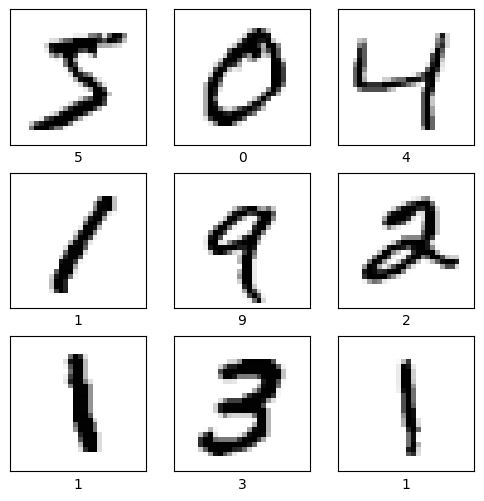

In [6]:
plt.figure(figsize = (6, 6))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images_mnist[i], cmap = 'binary')
    plt.xlabel(train_labels_mnist[i])

In [7]:
print(f'Shape matriz de treino: {train_images_mnist.shape}')
print(f'Shape matriz de teste: {test_images_mnist.shape}')

Shape matriz de treino: (60000, 28, 28)
Shape matriz de teste: (10000, 28, 28)


In [8]:
train_images_mnist[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

In [9]:
# Normalizando as matrizes

train_images = train_images_mnist/np.max(train_images_mnist)
test_images = test_images_mnist/np.max(test_images_mnist)

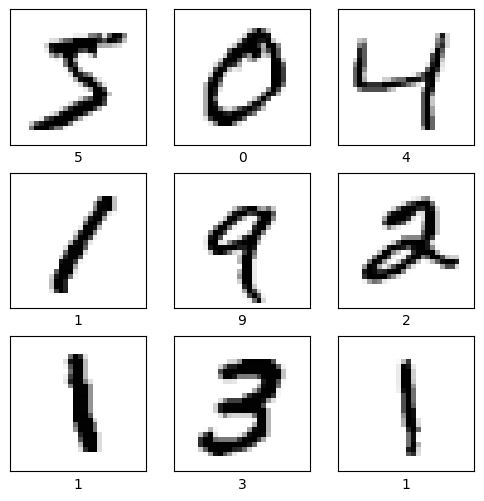

In [10]:
plt.figure(figsize = (6, 6))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images_mnist[i], cmap = 'binary')
    plt.xlabel(train_labels_mnist[i])

## 2.2. CIFAR100

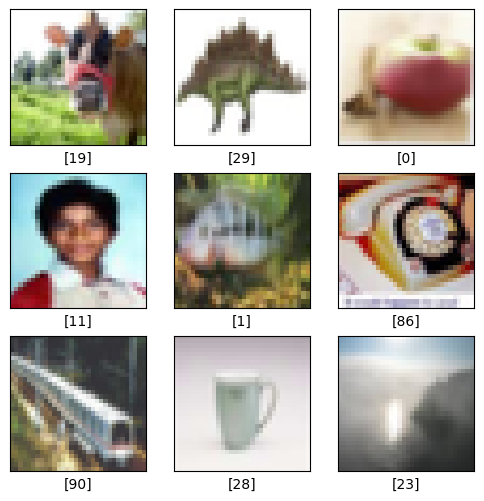

In [11]:
plt.figure(figsize = (6, 6))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images_cifar[i], cmap = 'binary')
    plt.xlabel(train_labels_cifar[i])

In [12]:
# Diferente do MNIST, agora temos imagens coloridas em 32x32 e com 3 canais (RGB!)
print(f'Shape matriz de treino: {train_images_cifar.shape}')
print(f'Shape matriz de teste: {test_images_cifar.shape}')

Shape matriz de treino: (50000, 32, 32, 3)
Shape matriz de teste: (10000, 32, 32, 3)


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [195, 205, 193],
        [212, 224, 204],
        [182, 194, 167]],

       [[255, 255, 255],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [170, 176, 150],
        [161, 168, 130],
        [146, 154, 113]],

       [[255, 255, 255],
        [254, 254, 254],
        [255, 255, 255],
        ...,
        [189, 199, 169],
        [166, 178, 130],
        [121, 133,  87]],

       ...,

       [[148, 185,  79],
        [142, 182,  57],
        [140, 179,  60],
        ...,
        [ 30,  17,   1],
        [ 65,  62,  15],
        [ 76,  77,  20]],

       [[122, 157,  66],
        [120, 155,  58],
        [126, 160,  71],
        ...,
        [ 22,  16,   3],
        [ 97, 112,  56],
        [141, 161,  87]],

       [[ 87, 122,  41],
        [ 88, 122,  39],
        [101, 134,  56],
        ...,
        [ 34,  36,  10],
        [105, 133,  59],
        [138, 173,  79]]], dtype=uint8)
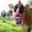

In [13]:
train_images_cifar[0]

In [14]:
# Normalizando as matrizes

train_images_cifar = train_images_cifar/np.max(train_images_cifar)
test_images_cifar = test_images_cifar/np.max(test_images_cifar)

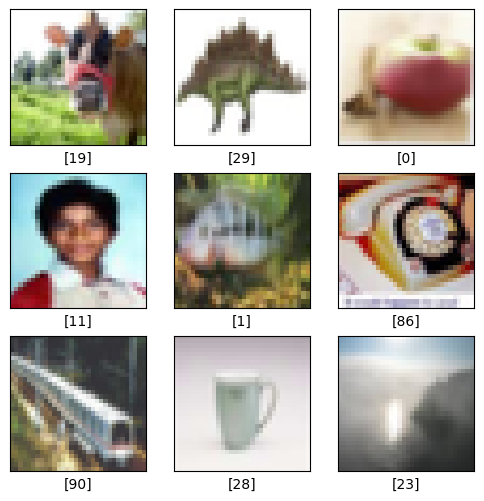

In [15]:
plt.figure(figsize = (6, 6))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images_cifar[i], cmap = 'binary')
    plt.xlabel(train_labels_cifar[i])

# 3. Modelos de Redes Neurais

## 3.1. MLP (Multi Layer Perceptron)

### 3.1.1. MLP MNIST

In [16]:
#   O MLP é um modelo totalmente conectado, isso significa que todos os neurônios de entrada são utilizados como
# input para os neurônios nas camadas ocultas
#   No modelos mais simples possível (camada de input, oculta e output), o modelo receberá como input 28*28 = 784

model_mlp = keras.Sequential([
    keras.layers.Flatten(input_shape = (28, 28)), # Camada de input: Flatten - transforma a matriz 28*28 em um vetor de 784 dimensoes
    keras.layers.Dense(128, activation = tf.nn.relu), # Camada oculta: 128 neurônios e função de ativação relu
    keras.layers.Dense(10, activation = tf.nn.softmax) # Camada de Output: 10 neurônios e função de ativação softmax
])

model_mlp.compile(loss = 'sparse_categorical_crossentropy', # sparse_categorical pois a saida (train_label) é sparsa (UMA coluna de 0 a 9)
                  metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model_mlp.fit(train_images_mnist, train_labels_mnist, epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8766 - loss: 2.3764
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9311 - loss: 0.5149
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9456 - loss: 0.4273
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9530 - loss: 0.3770
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9587 - loss: 0.3443
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9609 - loss: 0.3018
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9662 - loss: 0.2805
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9680 - loss: 0.2672
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9708 - loss: 0.2403
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9723 - loss: 0.2309


In [19]:
test_loss, test_acc = model_mlp.evaluate(test_images_mnist, test_labels_mnist)

print(f' Loss no teste: {test_loss:.4f}',
      '\n',
      f'Accuracy no teste: {test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9588 - loss: 0.5706
 Loss no teste: 0.5706 
 Accuracy no teste: 0.9588


### 3.1.2. MLP CIFAR100

In [20]:
#   O MLP é um modelo totalmente conectado, isso significa que todos os neurônios de entrada são utilizados como
# input para os neurônios nas camadas ocultas
#   No modelos mais simples possível (camada de input, oculta e output), o modelo receberá como input 28*28 = 784

model_mlp = keras.Sequential([
    keras.layers.Flatten(input_shape = (32, 32, 3)), # Camada de input: Flatten - transforma a matriz 28*28 em um vetor de 784 dimensoes
    keras.layers.Dense(256, activation = tf.nn.relu), # Camada oculta: 256 neurônios e função de ativação relu
    keras.layers.Dense(100, activation = tf.nn.softmax) # Camada de Output: 100 neurônios e função de ativação softmax
])

model_mlp.compile(loss = 'sparse_categorical_crossentropy', # sparse_categorical pois a saida (train_label) é sparsa (UMA coluna de 0 a 9)
                  metrics = ['accuracy'])

In [21]:
model_mlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 812,388 (3.10 MB)

 Trainable params: 812,388 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model_mlp.fit(train_images_cifar, train_labels_cifar, epochs = 10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0658 - loss: 4.1920
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.1117 - loss: 3.8666
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1245 - loss: 3.8051
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1274 - loss: 3.7886
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1330 - loss: 3.7810
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1315 - loss: 3.7798
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1332 - loss: 3.7762
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1304 - loss: 3.7883
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1318 - loss: 3.7966
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1298 - loss: 3.8017


In [23]:
test_loss, test_acc = model_mlp.evaluate(test_images_cifar, test_labels_cifar)

print(f' Loss no teste: {test_loss}',
      '\n',
      f'Accuracy no teste: {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1138 - loss: 3.9915
 Loss no teste: 3.9915480613708496 
 Accuracy no teste: 0.11379999667406082


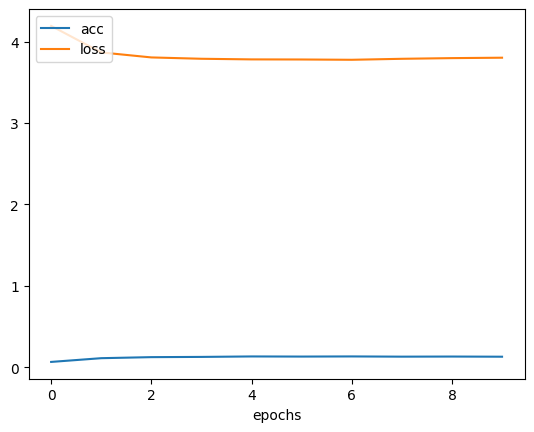

In [24]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])
plt.xlabel('epochs')
plt.legend(['acc', 'loss'], loc = 'upper left')
plt.show()

## 3.2. CNN (Convolutional Neural Network)

### 3.2.1. CNN com Flatten + Dense

In [24]:
model_cnn = keras.Sequential()

# --------------------- Camada de Convolução --------------------- #
# Convolução
model_cnn.add(keras.layers.Conv2D(filters = 32, # 32 filtros/kernels
                                  kernel_size = 5, # Dimensões do filtro/kernel
                                  padding = 'same',
                                  activation = 'relu', # Função de ativação
                                  input_shape = (32, 32, 3) # Dimensões do input
                                  ))
# Normalização
model_cnn.add(keras.layers.BatchNormalization())
# Pooling
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))
# Dropout
model_cnn.add(keras.layers.Dropout(0.2))

# --------------------- Camadas de Convolução --------------------- #
# Convolução
model_cnn.add(keras.layers.Conv2D(filters = 64,
                                  kernel_size = 5,
                                  padding = 'same',
                                  activation = 'relu'
                                  ))
# Normalização
model_cnn.add(keras.layers.BatchNormalization())
# Pooling
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))
# Dropout
model_cnn.add(keras.layers.Dropout(0.2))

# Convolução
model_cnn.add(keras.layers.Conv2D(filters = 128,
                                  kernel_size = 5,
                                  padding = 'same',
                                  activation = 'relu'
                                  ))
# Normalização
model_cnn.add(keras.layers.BatchNormalization())
# Pooling
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))
# Dropout
model_cnn.add(keras.layers.Dropout(0.2))

# Convolução
model_cnn.add(keras.layers.Conv2D(filters = 256,
                                  kernel_size = 5,
                                  padding = 'same',
                                  activation = 'relu'
                                  ))
# Normalização
model_cnn.add(keras.layers.BatchNormalization())
# Pooling
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))
# Dropout
model_cnn.add(keras.layers.Dropout(0.2))

# --------------------- Camadas Totalmente Conectadas --------------------- #
model_cnn.add(keras.layers.Flatten())
model_cnn.add(keras.layers.Flatten())
model_cnn.add(keras.layers.Dense(1024, activation = 'relu'))
model_cnn.add(keras.layers.Dropout(0.2))
model_cnn.add(keras.layers.Dense(512, activation = 'relu'))
model_cnn.add(keras.layers.Dropout(0.2))
model_cnn.add(keras.layers.Dense(100, activation = 'softmax'))

model_cnn.compile(optimizer = 'adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])
model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        51,30

 Total params: 2,705,700 (10.32 MB)

 Trainable params: 2,704,740 (10.32 MB)

 Non-trainable params: 960 (3.75 KB)

In [25]:
history = model_cnn.fit(train_images_cifar,
                        train_labels_cifar,
                        epochs = 10,
                        validation_split = 0.25)

test_loss, test_acc = model_cnn.evaluate(test_images_cifar, test_labels_cifar)

print(f' Loss no teste: {test_loss:.4f}',
      '\n',
      f'Accuracy no teste: {test_acc:.4f}')

Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.0883 - loss: 4.0083 - val_accuracy: 0.1118 - val_loss: 3.8286
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.1624 - loss: 3.4834 - val_accuracy: 0.1946 - val_loss: 3.2721
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.2120 - loss: 3.1955 - val_accuracy: 0.2464 - val_loss: 3.0579
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.2566 - loss: 2.9727 - val_accuracy: 0.2360 - val_loss: 3.1061
Epoch 5/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.2910 - loss: 2.7877 - val_accuracy: 0.3142 - val_loss: 2.7079
Epoch 6/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.3233 - loss: 2.6300 - val_accuracy: 0.3106 - val_loss: 2.7251
Epoch 7/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.3472 - loss: 2.4960 - val_accuracy: 0.3183 - val_loss: 2.6940
Epoch 8/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.3761 - loss: 2.3749 

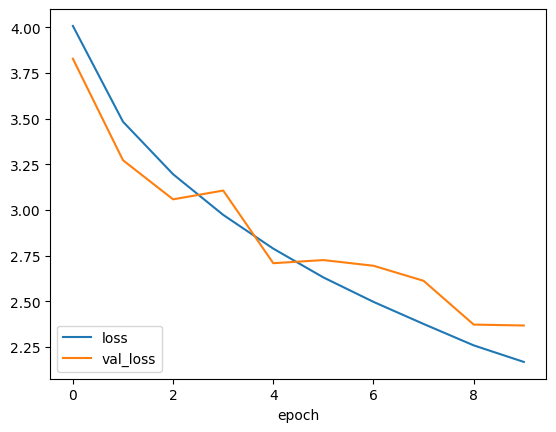

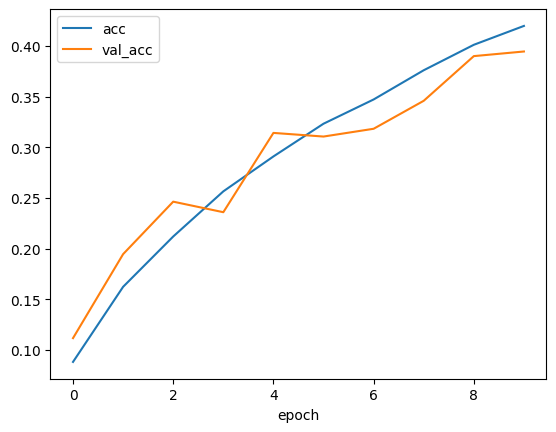

In [26]:
# Mostrar graficamente

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.legend(['loss', 'val_loss'], loc='lower left')
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.legend(['acc', 'val_acc'], loc='upper left')
plt.show()

### 3.2.2. CNN com GlobalAveragePooling2D()

In [25]:
model_cnn = keras.Sequential()

# --------------------- Camadas de Convolução --------------------- #
# Convolução
model_cnn.add(keras.layers.Conv2D(filters = 32, # 32 filtros/kernels
                                  kernel_size = 5, # Dimensões do filtro/kernel
                                  padding = 'same',
                                  activation = 'relu', # Função de ativação
                                  input_shape = (32, 32, 3) # Dimensões do input
                                  ))
# Normalização
model_cnn.add(keras.layers.BatchNormalization())
# Pooling
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))
# Dropout
model_cnn.add(keras.layers.Dropout(0.2))

# Convolução
model_cnn.add(keras.layers.Conv2D(filters = 64,
                                  kernel_size = 5,
                                  padding = 'same',
                                  activation = 'relu'
                                  ))
# Normalização
model_cnn.add(keras.layers.BatchNormalization())
# Pooling
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))
# Dropout
model_cnn.add(keras.layers.Dropout(0.2))

# Convolução
model_cnn.add(keras.layers.Conv2D(filters = 128,
                                  kernel_size = 5,
                                  padding = 'same',
                                  activation = 'relu'
                                  ))
# Normalização
model_cnn.add(keras.layers.BatchNormalization())
# Pooling
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))
# Dropout
model_cnn.add(keras.layers.Dropout(0.2))

# Convolução
model_cnn.add(keras.layers.Conv2D(filters = 256,
                                  kernel_size = 5,
                                  padding = 'same',
                                  activation = 'relu'
                                  ))
# Normalização
model_cnn.add(keras.layers.BatchNormalization())
# Pooling
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))
# Dropout
model_cnn.add(keras.layers.Dropout(0.2))


model_cnn.add(keras.layers.GlobalAveragePooling2D())
model_cnn.add(keras.layers.Dense(100,activation="softmax"))
model_cnn.compile(optimizer = 'adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])
model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,105,700 (4.22 MB)

 Trainable params: 1,104,740 (4.21 MB)

 Non-trainable params: 960 (3.75 KB)

In [26]:
history2 = model_cnn.fit(train_images_cifar,
                        train_labels_cifar,
                        epochs = 10,
                        validation_split = 0.25)

test_loss2, test_acc2 = model_cnn.evaluate(test_images_cifar, test_labels_cifar)

print(f' Loss no teste: {test_loss2:.4f}',
      '\n',
      f'Accuracy no teste: {test_acc2:.4f}')

Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.1645 - loss: 3.5706 - val_accuracy: 0.1707 - val_loss: 3.7476
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2951 - loss: 2.8155 - val_accuracy: 0.2454 - val_loss: 3.2038
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.3654 - loss: 2.4587 - val_accuracy: 0.3520 - val_loss: 2.5517
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4219 - loss: 2.1985 - val_accuracy: 0.3640 - val_loss: 2.5723
Epoch 5/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4674 - loss: 1.9974 - val_accuracy: 0.3871 - val_loss: 2.4420
Epoch 6/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5041 - loss: 1.8210 - val_accuracy: 0.4193 - val_loss: 2.3090
Epoch 7/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.5371 - loss: 1.6794 - val_accuracy: 0.4136 - val_loss: 2.3638
Epoch 8/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5679 - loss: 1.5

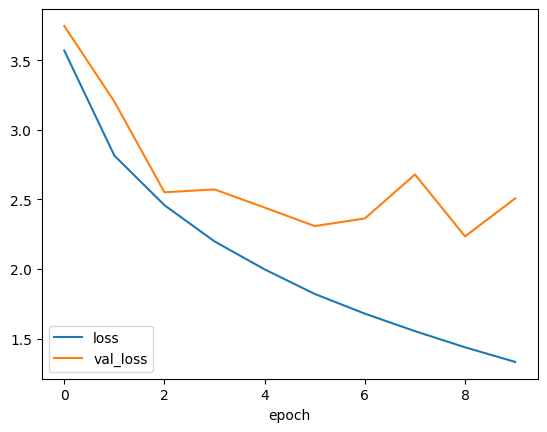

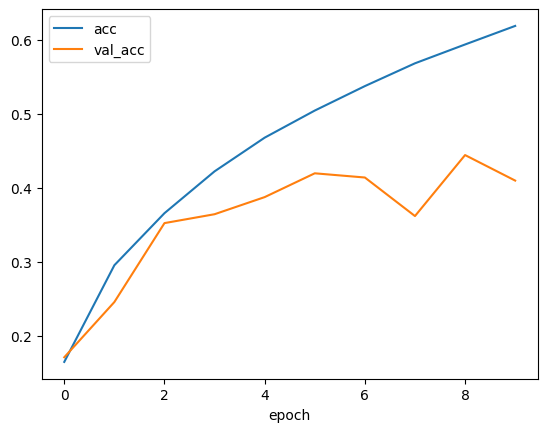

In [27]:
# Mostrar graficamente

plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.xlabel('epoch')
plt.legend(['loss', 'val_loss'], loc='lower left')
plt.show()

plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.xlabel('epoch')
plt.legend(['acc', 'val_acc'], loc='upper left')
plt.show()

In [28]:
imag_pred = model_cnn.predict(test_images_cifar)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


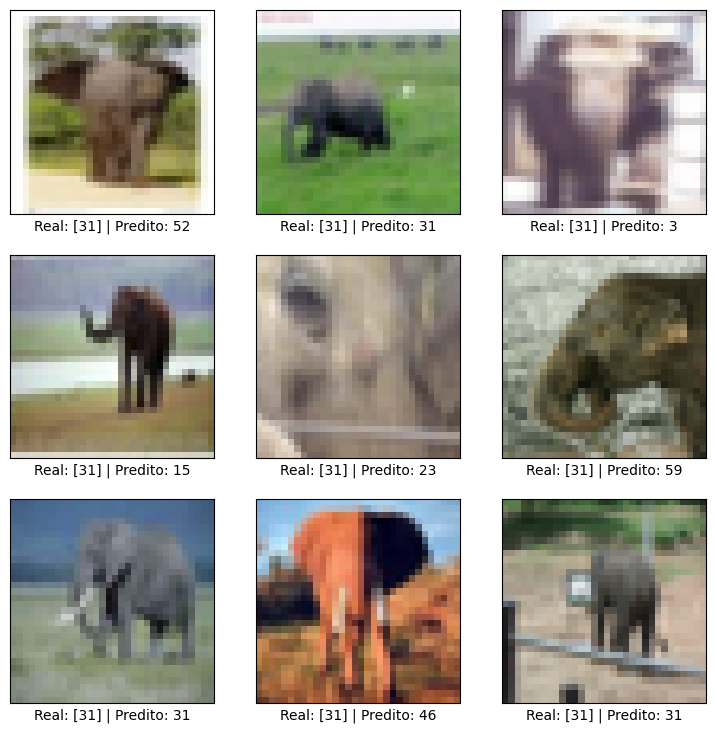

In [52]:
plt.figure(figsize=(9, 9))

# encontra índices onde o label é 1
idx_label_1 = np.where(test_labels_cifar == 31)[0]

for i in range(9):
    j = np.random.choice(idx_label_1)  # sorteia só entre label 1
    plt.subplot(3, 3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(test_images_cifar[j], cmap='binary')
    plt.xlabel(f'Real: {test_labels_cifar[j]} | Predito: {np.argmax(imag_pred[j])}')

# 4. Data Augmentation

O *Data Augmentation* é um algoritmo que faz manipulações aleatórias nas imagens de treino, como rotação, translação, cortes, borrões, etc. Assim são gerados de maneira **sintética**, mais exemplos únicos que serão utilizados no treino da Rede, esse fato deve refletir em uma melhora signficativa no desempenho do modelo.

In [53]:
# Repõe np.sctypes manualmente
np.sctypes = {
    "float": [np.float16, np.float32, np.float64],
    "int":   [np.int8, np.int16, np.int32, np.int64],
    "uint":  [np.uint8, np.uint16, np.uint32, np.uint64]
}

from imgaug import augmenters as iaa # Data Augmentation

seq = iaa.Sequential([
    iaa.Fliplr(0.2), # horizontal flips
    iaa.Crop(percent = (0, 0.1)), # random crops
    iaa.Sometimes(0.1,
                  iaa.GaussianBlur(sigma = (0, 0.25))),
    iaa.Affine(scale = {"x": (0.4, 0.6), "y": (0.4, 0.6)},
               translate_percent = {"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
               rotate = (-10, 10),
               shear = (-4, 4)
    )
], random_order = True)

In [54]:
# Aplicamos a sequência de augmenters 2 vezes
for i in range(2):
  train_images_cifar = np.vstack((train_images_cifar,
                                  seq.augment_images(train_images_cifar[:50000])))
  train_labels_cifar = np.vstack((train_labels_cifar,
                                  train_labels_cifar[:50000]) )

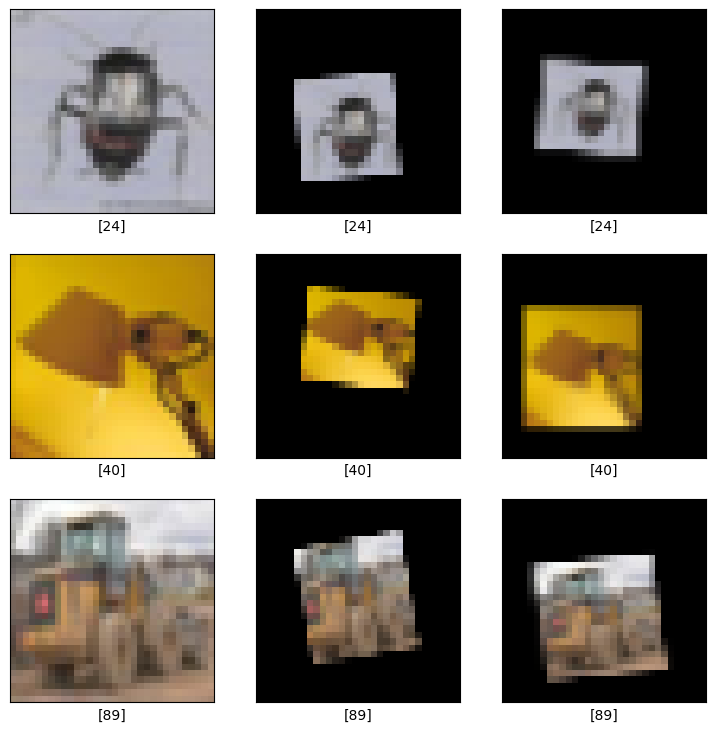

In [55]:
plt.figure(figsize= (9, 9))

for i in range(3):
    i_rand = np.random.randint(0, 10000)
    for j in range(3):
        k = j*50000+i_rand
        plt.subplot(3, 3, i*3 + j + 1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(train_images_cifar[k], cmap = 'binary')
        plt.xlabel(train_labels_cifar[k])

In [64]:
history3 = model_cnn.fit(train_images_cifar,
                        train_labels_cifar,
                        epochs = 25,
                        validation_split = 0.25)

test_loss3, test_acc3 = model_cnn.evaluate(test_images_cifar, test_labels_cifar)

print(f' Loss no teste: {test_loss3:.4f}',
      '\n',
      f'Accuracy no teste: {test_acc3:.4f}')

Epoch 1/25
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - accuracy: 0.5079 - loss: 1.8170 - val_accuracy: 0.4000 - val_loss: 2.3270
Epoch 2/25
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.5152 - loss: 1.7849 - val_accuracy: 0.4193 - val_loss: 2.2365
Epoch 3/25
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.5195 - loss: 1.7565 - val_accuracy: 0.4133 - val_loss: 2.2640
Epoch 4/25
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.5280 - loss: 1.7264 - val_accuracy: 0.4302 - val_loss: 2.1760
Epoch 5/25
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.5326 - loss: 1.7036 - val_accuracy: 0.4121 - val_loss: 2.2765
Epoch 6/25
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.5396 - loss: 1.6771 - val_accuracy: 0.4358 - val_loss: 2.1673
Epoch 7/25
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.5461 - loss: 1.6505 - val_accuracy: 0.4392 - val_loss: 2.1464
Epoch 8/25
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.5502 - loss: 1

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


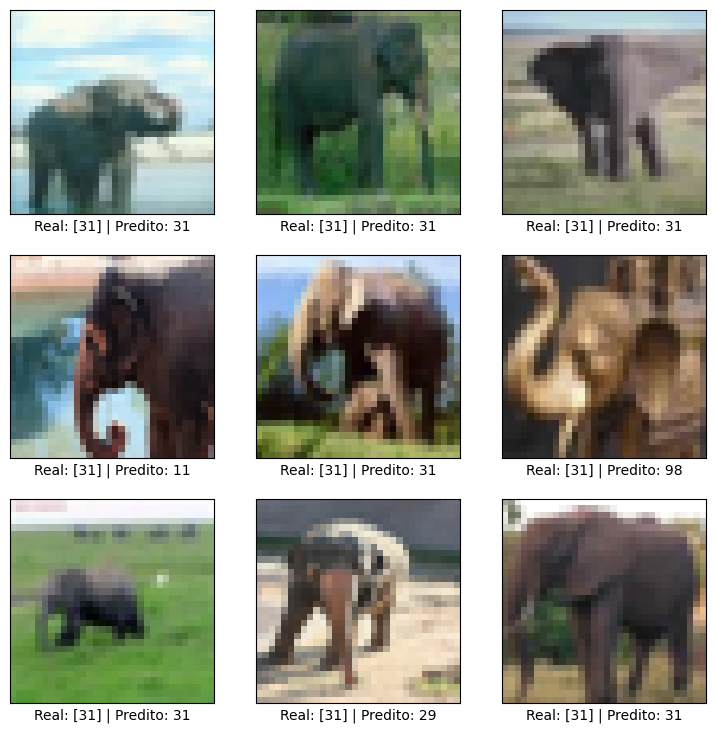

In [65]:
imag_pred3 = model_cnn.predict(test_images_cifar)

plt.figure(figsize=(9, 9))

# encontra índices onde o label é 1
idx_label_1 = np.where(test_labels_cifar == 31)[0]

for i in range(9):
    j = np.random.choice(idx_label_1)  # sorteia só entre label 1
    plt.subplot(3, 3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(test_images_cifar[j], cmap='binary')
    plt.xlabel(f'Real: {test_labels_cifar[j]} | Predito: {np.argmax(imag_pred3[j])}')

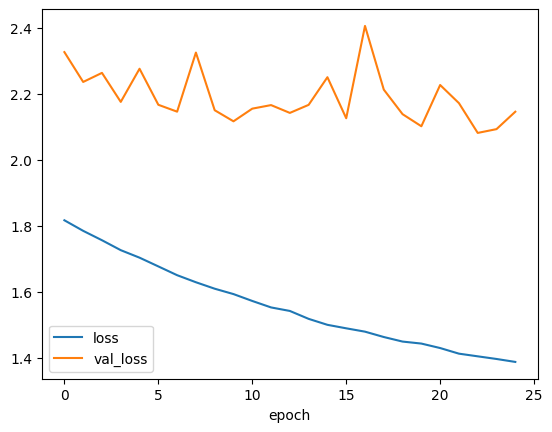

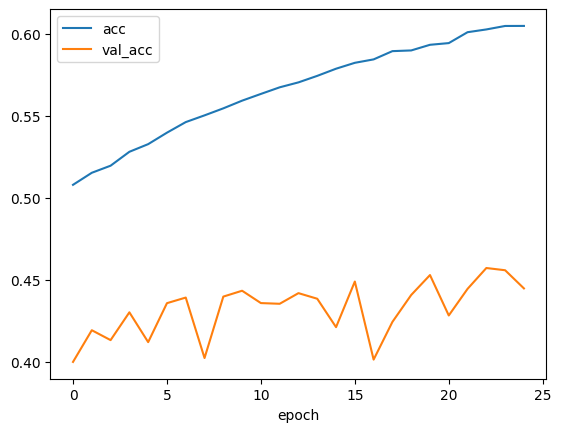

In [66]:
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.xlabel('epoch')
plt.legend(['loss', 'val_loss'], loc='lower left')
plt.show()

plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.xlabel('epoch')
plt.legend(['acc', 'val_acc'], loc='upper left')
plt.show()